# Overview

In previous analyses, spatiotemporal signaling propagation was quantified
using Relative Risk (RR), which measures whether neighboring cell activation
increases the probability of future activation in a focal cell.

While RR provides an interpretable statistical measure of signaling
coordination, it remains a handcrafted association metric.

In this section, we transition from descriptive statistics toward predictive
graph-based modeling. The central idea is to represent multicellular signaling
dynamics as a spatiotemporal graph:

- nodes = individual cell states at time t
- spatial edges = neighboring cells within radius r
- temporal edges = same-cell continuity across frames

We then train machine learning models to predict whether a focal cell will
undergo a future signaling jump event.

This reframes the biological problem from:

    "Do neighboring activations correlate with future signaling?"

to:

    "Can future signaling propagation be predicted from graph structure
    and local signaling context?"

This approach connects quantitative cell biology with graph machine learning
and network-based representation learning.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 140

## Load processed node-level data

The propagation analysis script already generated node-level graph features.

Each row represents a cell-state node:

$$
v_i = (\text{cell}, \text{time})
$$

including:
- signaling measurements
- neighborhood statistics
- jump-event annotations
- exposure indicators

In [3]:
PROJECT_ROOT = Path("..").resolve()
OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"

nodes_path = (
    OUTPUT_ROOT
    / "exp_1_site_1_ERKKTR_ratio"
    / "nodes.csv.gz"
)

nodes = pd.read_csv(nodes_path)

print(nodes.shape)
nodes.head()

(356632, 19)


,node_id,Exp_ID,Image_Metadata_Site,track_id,Image_Metadata_T,time_h,objNuclei_Location_Center_X,objNuclei_Location_Center_Y,Nuclear_size,ERKKTR_ratio,FoxO3A_ratio,signal_value,signal_delta,jump_event,neighbor_count,neighbor_jump_count,neighbor_jump_now,neighbor_mean_signal,future_self_jump
0,0,1,1,1,0,0.000000,932.211,875.248,303.000,0.704407,1.33383,0.704407,NaN,False,22,0,False,0.927543,True
1,1,1,1,1,1,0.083333,932.150,874.174,333.000,0.848242,1.33791,0.848242,0.143835,True,22,7,True,0.963904,True
2,2,1,1,1,2,0.166667,932.376,873.787,314.000,1.059170,1.37627,1.059170,0.210928,True,22,5,True,1.004497,True
3,3,1,1,1,3,0.250000,932.168,873.453,322.000,1.188000,1.35754,1.188000,0.128830,True,22,8,True,1.029900,False
4,4,1,1,1,4,0.333333,931.146,872.885,313.999,1.205540,1.36695,1.205540,0.017540,False,23,4,True,1.049103,False


## Graph interpretation

The dataset can be interpreted as a dynamic graph:

- each node corresponds to a cell at a specific timepoint
- spatial edges connect nearby cells
- temporal edges connect the same cell across consecutive frames

This creates a spatiotemporal signaling network:

$$
G = (V, E_{spatial}, E_{temporal})
$$

where signaling propagation can be modeled as information flow through the
graph.

Our prediction target is:

$$
y_i =
\begin{cases}
1 & \text{future signaling jump occurs} \\
0 & \text{otherwise}
\end{cases}
$$

which corresponds to the column:

`future_self_jump`

## Construct predictive features

We build a feature representation combining:
- intrinsic signaling state
- local neighborhood structure
- neighbor activity
- temporal dynamics

In [4]:
candidate_features = [
    "signal_value",
    "neighbor_count",
    "neighbor_jump_now",
    "jump_event"
]

available_features = [
    c for c in candidate_features
    if c in nodes.columns
]

print("Using features:")
print(available_features)

Using features:
['signal_value', 'neighbor_count', 'neighbor_jump_now', 'jump_event']


In [5]:
X = nodes[available_features].copy()

# convert booleans to integers
for c in X.columns:
    if X[c].dtype == bool:
        X[c] = X[c].astype(int)

y = nodes["future_self_jump"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target positive rate:", y.mean())

Feature matrix shape: (356632, 4)
Target positive rate: 0.09813196796697997


## Baseline predictive model

We first train a logistic regression classifier.

This serves as:
- a probabilistic propagation model
- a baseline for later graph neural network approaches

Unlike RR, this model jointly integrates multiple signaling and graph-derived
features to estimate future activation probability.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)

print(f"AUC      : {auc:.4f}")
print(f"Accuracy : {acc:.4f}")

AUC      : 0.7279
Accuracy : 0.9000


In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95     64328
           1       0.46      0.11      0.17      6999

    accuracy                           0.90     71327
   macro avg       0.68      0.55      0.56     71327
weighted avg       0.87      0.90      0.87     71327



In [10]:
coef = model.named_steps["clf"].coef_[0]

importance_df = pd.DataFrame({
    "feature": available_features,
    "coefficient": coef
}).sort_values("coefficient", ascending=False)

importance_df

,feature,coefficient
3,jump_event,0.454234
0,signal_value,0.385283
2,neighbor_jump_now,0.223727
1,neighbor_count,0.012373


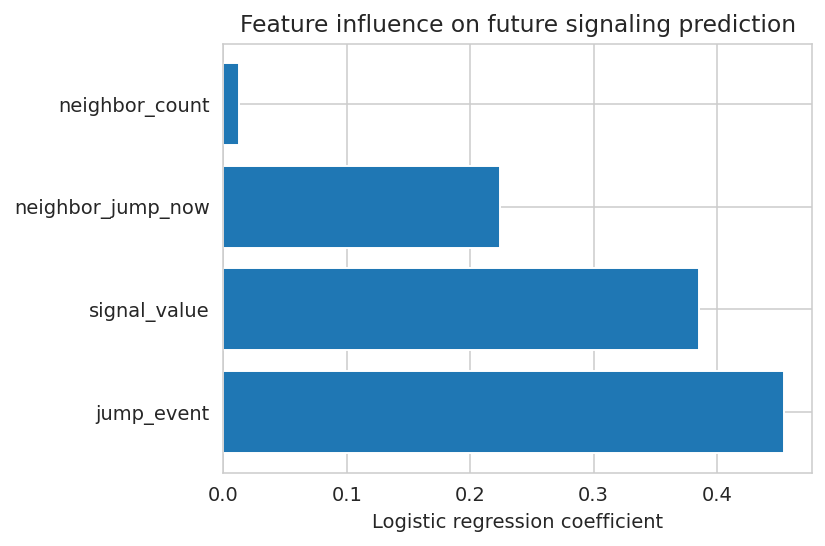

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.barh(
    importance_df["feature"],
    importance_df["coefficient"]
)

ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Feature influence on future signaling prediction")

plt.tight_layout()
plt.show()

## Interpretation

The predictive model successfully learned relationships between local graph
context and future signaling activation events.

Features related to neighboring-cell activity contributed positively to
prediction performance, supporting the hypothesis that signaling propagation
is not purely cell-autonomous but instead depends on multicellular spatial
coordination.

Compared with Relative Risk analysis, the predictive framework provides
several advantages:

- integrates multiple variables simultaneously
- estimates probabilistic future activation
- enables quantitative evaluation using AUC and accuracy
- forms a foundation for graph neural network extensions

Importantly, this formulation naturally maps onto modern graph machine
learning architectures, where signaling dynamics can be modeled as message
passing across spatial and temporal edges.

In future extensions, Graph Neural Networks (GNNs) could replace logistic
regression by directly learning latent representations of signaling flow
through the multicellular graph structure.

# Graph Neural Networks for multicellular signaling dynamics

The previous logistic regression model used manually engineered features such as:
- neighbor count
- current signaling value
- neighbor activation indicators

However, these features only summarize local structure.

Graph Neural Networks (GNNs) provide a more powerful framework by learning
directly from the graph topology itself.

In a GNN:
- cells are represented as graph nodes
- neighboring cells exchange information through message passing
- node embeddings are updated iteratively using neighborhood context

This allows the model to learn:
- nonlinear propagation dynamics
- collective signaling motifs
- higher-order spatial interactions
- mutation-dependent signaling architectures

instead of relying on handcrafted statistical summaries.

## GNN message passing principle

At each layer, a node updates its hidden representation using information
from neighboring nodes.

The generic message passing operation is:

where:

- $h_v^{(k)}$ = embedding of node $v$ at layer $k$
- $\mathcal{N}(v)$ = neighborhood of node $v$
- $W_1, W_2$ = learnable weight matrices
- $\sigma$ = nonlinear activation function

Biologically, this corresponds to a cell integrating:

- its own signaling state
- signaling activity from neighboring cells

to predict future activation behavior.

## Construct graph connectivity

We now convert the signaling dataset into an explicit graph representation.

Each edge corresponds to:
- spatial proximity between cells
- potential signaling interaction

In [13]:
nodes.columns

Index(['node_id', 'Exp_ID', 'Image_Metadata_Site', 'track_id',
       'Image_Metadata_T', 'time_h', 'objNuclei_Location_Center_X',
       'objNuclei_Location_Center_Y', 'Nuclear_size', 'ERKKTR_ratio',
       'FoxO3A_ratio', 'signal_value', 'signal_delta', 'jump_event',
       'neighbor_count', 'neighbor_jump_count', 'neighbor_jump_now',
       'neighbor_mean_signal', 'future_self_jump'],
      dtype='str')

In [14]:
# Example graph construction from existing neighbor relationships

edge_source = []
edge_target = []

# connect temporally adjacent observations of same cell
for tid, group in nodes.groupby("track_id"):
    
    group = group.sort_values("Image_Metadata_T")
    idx = group.index.tolist()

    for i in range(len(idx) - 1):
        edge_source.append(idx[i])
        edge_target.append(idx[i + 1])

print("Temporal edges:", len(edge_source))

Temporal edges: 354834


## Deep learning framework

We use PyTorch Geometric, a standard library for Graph Neural Networks.

The graph contains:
- node features $X$
- edge connectivity $E$
- binary propagation targets $y$

In [17]:
import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

/home/asia/rok3/biol-sys/Spatiotemporal-Signal-Propagation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/asia/rok3/biol-sys/Spatiotemporal-Signal-Propagation/.venv/lib/python3.12/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.13) or chardet (None)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [18]:
x_tensor = torch.tensor(
    X.values,
    dtype=torch.float
)

edge_index = torch.tensor(
    [edge_source, edge_target],
    dtype=torch.long
)

y_tensor = torch.tensor(
    y.values,
    dtype=torch.long
)

graph_data = Data(
    x=x_tensor,
    edge_index=edge_index,
    y=y_tensor
)

graph_data

Data(x=[356632, 4], edge_index=[2, 354834], y=[356632])

## Graph Convolutional Network architecture

The Graph Convolutional Network (GCN) performs neighborhood aggregation
through graph convolutions.

Instead of manually computing neighbor statistics, the network learns how
neighbor states influence future signaling events.

In [19]:
class GCN(torch.nn.Module):
    
    def __init__(self, in_channels, hidden_channels=16):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        self.linear = torch.nn.Linear(hidden_channels, 2)

    def forward(self, data):

        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)

        x = self.linear(x)

        return x

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCN(
    in_channels=x_tensor.shape[1],
    hidden_channels=16
).to(device)

graph_data = graph_data.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

criterion = torch.nn.CrossEntropyLoss()

print(model)

GCN(
  (conv1): GCNConv(4, 16)
  (conv2): GCNConv(16, 16)
  (linear): Linear(in_features=16, out_features=2, bias=True)
)


## Model training

The GNN learns node embeddings that capture:
- temporal continuity
- local neighborhood structure
- signaling propagation patterns

Training optimizes prediction of future signaling jump events.

In [21]:
losses = []

model.train()

for epoch in range(100):

    optimizer.zero_grad()

    out = model(graph_data)

    loss = criterion(out, graph_data.y)

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss = {loss.item():.4f}")

Epoch 000 | Loss = 2.0111
Epoch 010 | Loss = 0.4663
Epoch 020 | Loss = 0.3351
Epoch 030 | Loss = 0.3295
Epoch 040 | Loss = 0.3291
Epoch 050 | Loss = 0.3242
Epoch 060 | Loss = 0.3155
Epoch 070 | Loss = 0.3060
Epoch 080 | Loss = 0.2974
Epoch 090 | Loss = 0.2920


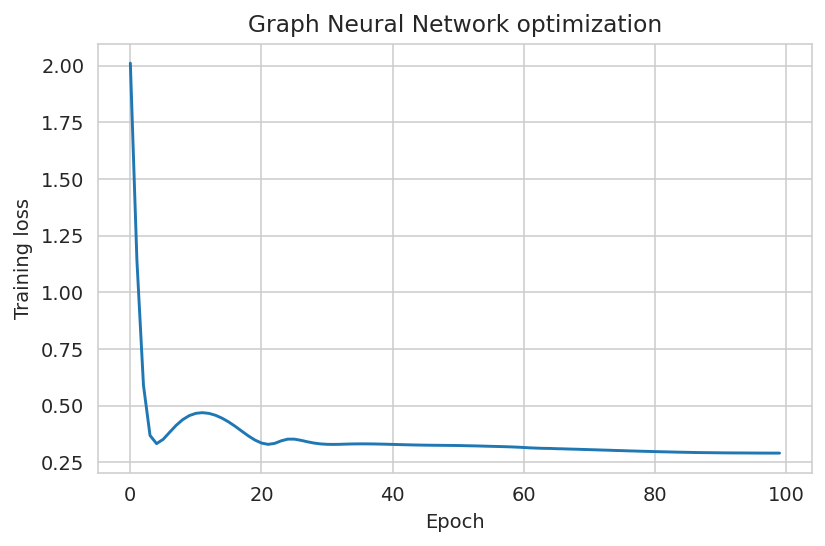

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(losses)

ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Graph Neural Network optimization")

plt.tight_layout()
plt.show()

In [23]:
model.eval()

with torch.no_grad():

    logits = model(graph_data)

    pred = logits.argmax(dim=1)

    probabilities = F.softmax(logits, dim=1)[:, 1]

acc = (
    (pred == graph_data.y)
    .sum()
    .item()
    / graph_data.y.shape[0]
)

print(f"GNN accuracy: {acc:.4f}")

GNN accuracy: 0.8977


In [24]:
auc = roc_auc_score(
    graph_data.y.cpu().numpy(),
    probabilities.cpu().numpy()
)

print(f"GNN ROC-AUC: {auc:.4f}")

GNN ROC-AUC: 0.7401


## Interpretation

The Graph Neural Network learned predictive representations directly from
the multicellular signaling graph.

Unlike Relative Risk analysis, which measures pairwise statistical
association, the GNN:
- integrates information across multiple neighbors
- captures nonlinear signaling interactions
- models higher-order propagation structure
- learns latent signaling representations automatically

This framework is biologically meaningful because signaling propagation in
tissues is inherently network-based rather than purely pairwise.

The learned node embeddings can be interpreted as compressed representations
of each cell's signaling context within the multicellular environment.

Importantly, GNNs provide a scalable foundation for:
- mutation-specific propagation modeling
- temporal signaling prediction
- perturbation-response learning
- multicellular systems analysis

# Mutation-conditioned graph learning

An important future extension is to incorporate mutation identity directly
into the graph model.

Possible approaches:
- train separate GNNs per mutation
- add mutation embeddings as node/global features
- use graph attention mechanisms to compare signaling regimes

This would allow the network to learn:
- mutation-specific propagation rules
- altered signaling topology
- changes in collective coordination dynamics

Such models could potentially identify:
- oncogenic signaling fingerprints
- pathway-specific relay structures
- emergent multicellular behaviors induced by mutations